
# PCA-Dimensionsreduktion


Nur mit numerischen Daten durchführen (keine One-Hot-Encoded)


In [13]:
import pandas as pd
import numpy as np

from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
df = pd.read_csv("One-Hot-Encoded.csv")

df = df.select_dtypes(include=["number"]).copy()




## Numerische Features auswählen



In [15]:
X = df.select_dtypes(include=[np.number])

print("Numerische Matrix vor dropna:", X.shape)

X = X.dropna(axis=0)

print("Numerische Matrix nach dropna:", X.shape)


q98 = df["ConvertedCompTotal"].dropna().quantile(0.95)
df = df[df["ConvertedCompTotal"] <= q98].copy()

years_q98 = df["YearsCode"].dropna().quantile(0.95)
df = df[df["YearsCode"] <= years_q98].copy()

exp_q98 = df["WorkExp"].dropna().quantile(0.95)
df = df[df["WorkExp"] <= exp_q98].copy()

sat_q98 = df["JobSat"].dropna().quantile(0.95)
df = df[df["JobSat"] <= sat_q98].copy()

# drop convertedcompyearly from x
X = X.drop("ConvertedCompTotal", axis=1)
X = X.drop("CompTotal", axis=1)
X = X.drop("MaxAge", axis=1)

X.head()


Numerische Matrix vor dropna: (47514, 9)
Numerische Matrix nach dropna: (15651, 9)


,AgeNum,WorkExp,YearsCode,RemoteCategoryNum,ConvertedCompYearly,JobSat
0,29.0,8.0,14.0,0.00,61256.0,10.0
1,29.0,2.0,10.0,0.25,104413.0,9.0
3,39.0,4.0,5.0,0.00,36197.0,6.0
7,39.0,22.0,30.0,0.00,72000.0,6.0
8,29.0,9.0,15.0,0.00,70000.0,8.0



## Pipeline und PCA



In [16]:
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)

dim_reduction = PCA(n_components=0.9)

pipeline_2 = Pipeline([
    ("scaler", scaler),
    ("dim_reduction", dim_reduction)
])

X_pca = pipeline_2.fit(X_scaled)

X_pca

,steps,"[('scaler', ...), ('dim_reduction', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,0.9
,copy,True
,whiten,False
,svd_solver,'auto'


In [17]:
X_pca = pipeline_2.fit_transform(X)

print("PCA-Ergebnisform:", X_pca.shape)
print("Erklärte Varianz gesamt:",
      pipeline_2.named_steps["dim_reduction"].explained_variance_ratio_.sum())

X_pca      


PCA-Ergebnisform: (15651, 4)
Erklärte Varianz gesamt: 0.9505321538803265


array([[-0.74241341,  1.67663467, -0.79086118, -0.52307457],
       [-1.4343019 ,  1.14880827, -0.38287511,  0.00883292],
       [-1.09073131,  0.22955732,  0.51062244, -1.25988258],
       ...,
       [ 1.05076543,  1.05584996, -0.92900468,  0.17058004],
       [-1.51361184, -0.18246267, -0.66104165,  0.68639914],
       [-1.72198925, -0.11218396,  0.29112248, -0.78988497]],
      shape=(15651, 4))


## 2D-Plot




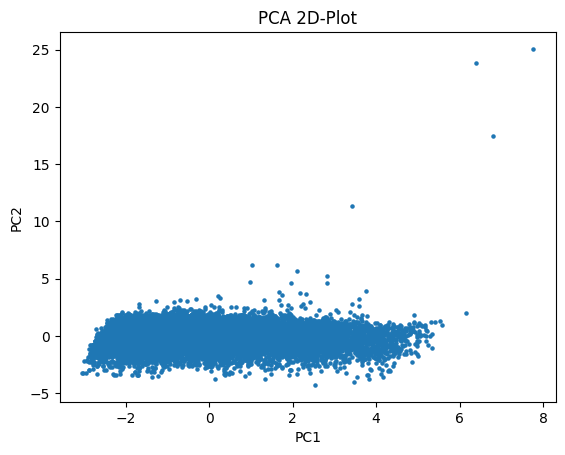

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D-Plot")
plt.show()
